In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_pip = pd.read_csv('Data/Clean/IMF_CPIS.csv') # Manually set to CPIS for now
df_iip = pd.read_csv('Data/Clean/IMF_IIP.csv')
df_mkt = pd.read_csv('Data/Clean/market_cap_with_predictions.csv')

display(df_pip.head(3))
display(df_iip.head(3))
display(df_mkt.head(3))

,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,COMP_BREAKDOWN_1,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3,COMP_BREAKDOWN_3_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,year,value,iso3_i,iso3_j
0,ARG,Argentina,IMF_CPIS_I_A_D_L_T_BP6,"Assets, Debt Securities",IMF_CNT_COUNTRY_1,World,IMF_CNT_SEC_T,Total Holdings,IMF_SEC_T,Sector: All sectors,USD,US dollars,1997,1.805003e+10,ARG,NaN
1,ARG,Argentina,IMF_CPIS_I_A_D_L_T_BP6,"Assets, Debt Securities",IMF_CNT_COUNTRY_111,United States,IMF_CNT_SEC_T,Total Holdings,IMF_SEC_T,Sector: All sectors,USD,US dollars,1997,3.558190e+09,ARG,USA
2,ARG,Argentina,IMF_CPIS_I_A_D_L_T_BP6,"Assets, Debt Securities",IMF_CNT_COUNTRY_112,United Kingdom,IMF_CNT_SEC_T,Total Holdings,IMF_SEC_T,Sector: All sectors,USD,US dollars,1997,1.285639e+06,ARG,GBR


,iso3_i,iso3_j,year,value
0,PHL,PHL,2012,38930.738978
1,IND,IND,2012,128932.422019
2,KEN,KEN,2012,381.742164


,iso3,Year,Market Cap,countrycode,year,Real GDP,Capital Stock,Market Cap / Real GDP,Market Cap / Capital Stock,Market Cap Predicted
0,AUT,2010,1.260320e+11,AUT,2010,4.897142e+08,2.652521e+09,257.358213,47.514025,1.137729e+11
1,BEL,2010,2.687263e+11,BEL,2010,5.605082e+08,3.032535e+09,479.433247,88.614414,3.437195e+11
2,BGR,2010,7.376360e+09,BGR,2010,1.455786e+08,3.382115e+08,50.669263,21.809905,1.064066e+10


In [7]:
# Get year ranges for each
print("PIP Year Range:", df_pip['year'].min(), "-", df_pip['year'].max())
print("IIP Year Range:", df_iip['year'].min(), "-", df_iip['year'].max())
print("Market Cap Year Range:", df_mkt['year'].min(), "-", df_mkt['year'].max())

PIP Year Range: 1997 - 2023
IIP Year Range: 2012 - 2025
Market Cap Year Range: 2010 - 2023


In [8]:
# Get sum of flows from PIP per iso3_i and year
pip_agg_yr = df_pip.groupby(['iso3_i', 'year'])["value"].sum().reset_index()
iip_agg_yr = df_iip.groupby(['iso3_i', 'year'])["value"].sum().reset_index()

,iso3_i,year,value
501,DEU,2023,6.814311e+13
500,DEU,2022,5.974947e+13
499,DEU,2021,7.228109e+13


,iso3_i,year,value
422,DEU,2024,1.380548e+06
421,DEU,2023,1.304581e+06
420,DEU,2022,1.090817e+06


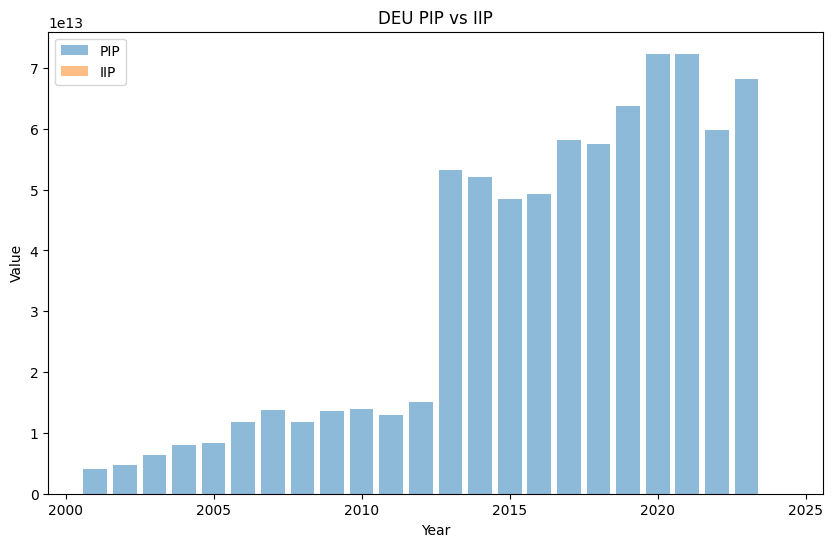

In [9]:
# Inspect DEU to see how similar they are
deu_pip = pip_agg_yr[pip_agg_yr['iso3_i'] == 'DEU'].sort_values('year', ascending=False)
deu_iip = iip_agg_yr[iip_agg_yr['iso3_i'] == 'DEU'].sort_values('year', ascending=False)

display(deu_pip.head(3))
display(deu_iip.head(3))

# Plot on bar chart
plt.figure(figsize=(10, 6))
plt.bar(deu_pip['year'], deu_pip['value'], label='PIP', alpha=0.5)
plt.bar(deu_iip['year'], deu_iip['value'], label='IIP', alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('DEU PIP vs IIP')
plt.legend()
plt.show()